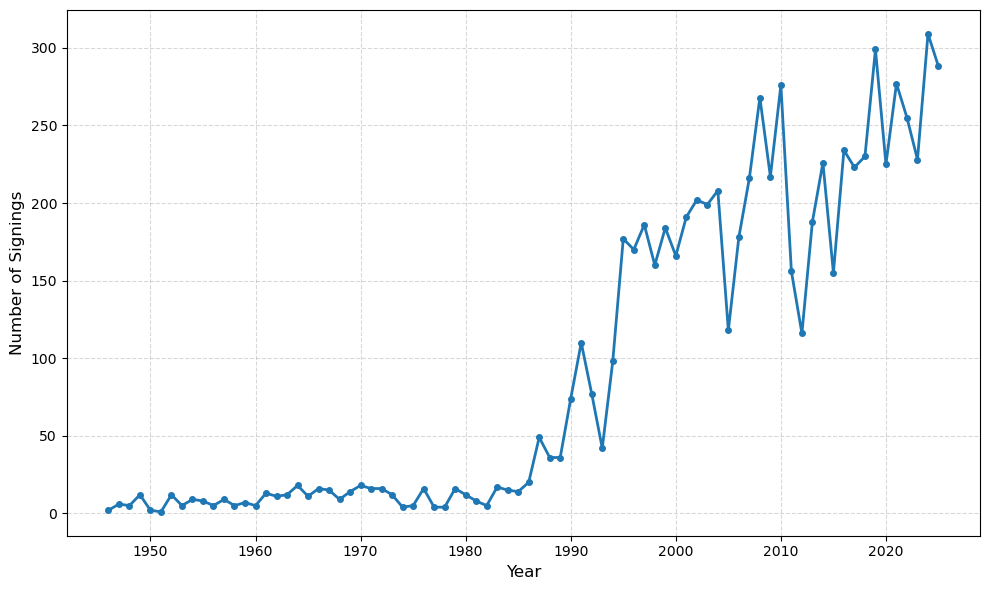

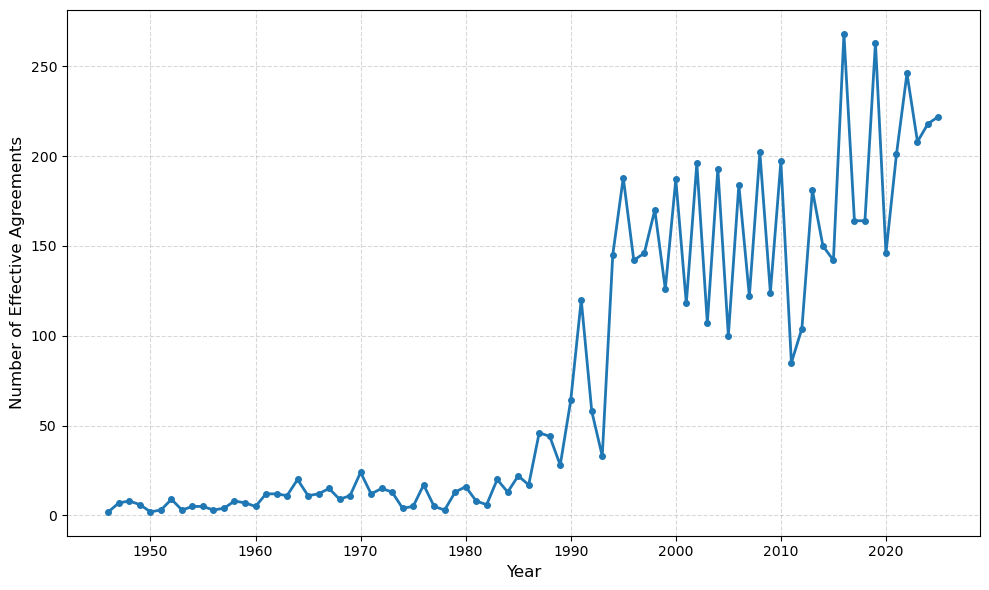

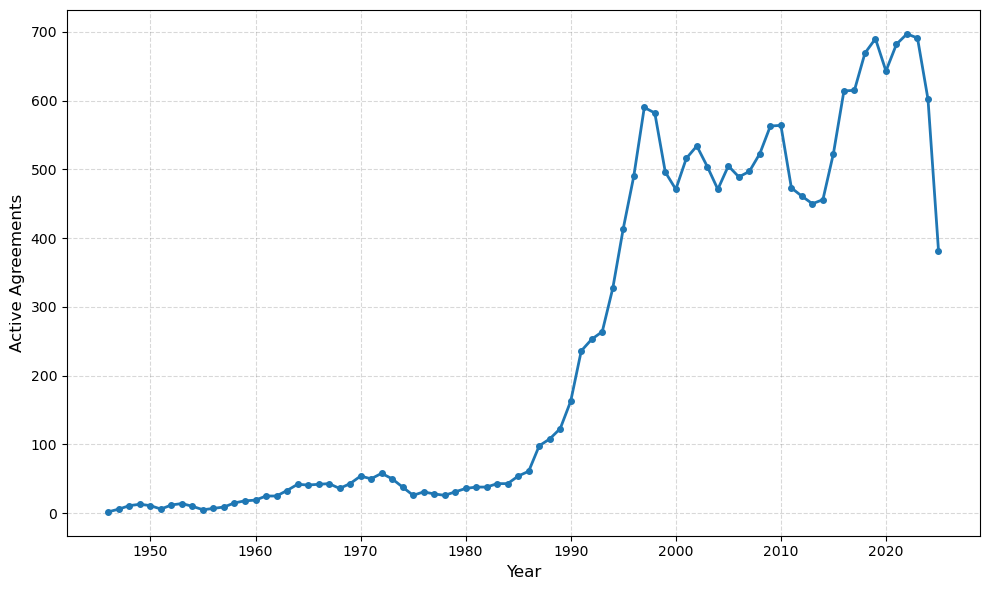

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the Italy dataset
df = pd.read_csv('Italy_metadata.csv')

# 2. Helper function to parse Italian 2-digit years (e.g., '3/26/26')
def fix_2digit_year(date_str):
    if pd.isna(date_str):
        return pd.NaT
    try:
        parts = str(date_str).split(' ')[0].split('/')
        if len(parts) != 3:
            return pd.to_datetime(date_str, errors='coerce')
        m, d, y = parts
        y_int = int(y)
        # Standard logic: 00-26 is 2000s, everything else is 1900s
        full_year = 2000 + y_int if y_int <= 26 else 1900 + y_int
        return pd.Timestamp(year=full_year, month=int(m), day=int(d))
    except:
        return pd.to_datetime(date_str, errors='coerce')

# 3. Apply date parsing to standardized column names
df['date_signing'] = df['Stipula'].apply(fix_2digit_year)
df['date_effective'] = df['Decorrenza'].apply(fix_2digit_year)
df['date_expiry'] = df['Scadenza Contrattuale'].apply(fix_2digit_year)

# ---------------------------------------------------------
# PLOT 1: SIGNING DATE (STIPULA)
# ---------------------------------------------------------
df_sign = df[df['date_signing'].dt.year < 2026].dropna(subset=['date_signing'])
sign_counts = df_sign['date_signing'].dt.year.value_counts().sort_index()

plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
plt.plot(sign_counts.index, sign_counts.values, marker='o', linestyle='-', linewidth=2, markersize=4)
#plt.title('Italy: Collective Agreement Signings by Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Signings', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, color='gray')
plt.tight_layout()
plt.savefig('italy_plot_signing.png')

# ---------------------------------------------------------
# PLOT 2: EFFECTIVE DATE (DECORRENZA)
# ---------------------------------------------------------
df_eff = df[df['date_effective'].dt.year < 2026].dropna(subset=['date_effective'])
eff_counts = df_eff['date_effective'].dt.year.value_counts().sort_index()

plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
plt.plot(eff_counts.index, eff_counts.values, marker='o', linestyle='-', linewidth=2, markersize=4)
#plt.title('Italy: Effective Dates by Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Effective Agreements', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, color='gray')
plt.tight_layout()
plt.savefig('italy_plot_effective.png')

# ---------------------------------------------------------
# PLOT 3: ACTIVE AGREEMENTS (Overlap logic)
# ---------------------------------------------------------
# If it's active for even a day in that year it counts
df_active_raw = df.dropna(subset=['date_effective', 'date_expiry'])
df_active_raw = df_active_raw[df_active_raw['date_effective'].dt.year < 2026]

start_year = int(df_active_raw['date_effective'].dt.year.min())
years_range = range(start_year, 2026)
counts_active = []

for year in years_range:
    year_start = pd.Timestamp(year=year, month=1, day=1)
    year_end = pd.Timestamp(year=year, month=12, day=31)
    # Count if the agreement duration overlaps with the year [Jan 1, Dec 31]
    count = ((df_active_raw['date_effective'] <= year_end) & 
             (df_active_raw['date_expiry'] >= year_start)).sum()
    counts_active.append(count)

plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
plt.plot(years_range, counts_active, marker='o', linestyle='-', linewidth=2, markersize=4)
#plt.title('Italy: Number of Active Agreements by Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Active Agreements', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, color='gray')
plt.tight_layout()
plt.savefig('italy_plot_active.png')